<h2><center>AI for Sustainable Development</center></h2>
<h3>Predicting Students' Dropout and Academic Success</h3>


Description of Dataset:

A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies.

The dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters.
The data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification task, in which there is a strong imbalance towards one of the classes.



In [2]:
from ucimlrepo import fetch_ucirepo, list_available_datasets
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
#from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score, classification_report, accuracy_score, precision_score, recall_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [3]:
list_available_datasets()

-------------------------------------
The following datasets are available:
-------------------------------------
Dataset Name                                                                            ID    
------------                                                                            --    
Abalone                                                                                 1     
Adult                                                                                   2     
Annealing                                                                               3     
Audiology (Standardized)                                                                8     
Auto MPG                                                                                9     
Automobile                                                                              10    
Balance Scale                                                                           12    
Balloons                       

In [ ]:
#fetch data
education = fetch_ucirepo(id=697)

# Extrating features
X = education.data.features
y = education.data.targets

# Meta Data
print(education.metadata)

# Variable Information
print(education.variables)

{'uci_id': 697, 'name': "Predict Students' Dropout and Academic Success", 'repository_url': 'https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success', 'data_url': 'https://archive.ics.uci.edu/static/public/697/data.csv', 'abstract': "A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies.\nThe dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. \nThe data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification task, in which there is a strong imbalance towards one of the classes.", 'area': 'Social Sc

### Exploring the Features (X) Dataframe:

In [ ]:
# Display data of our 5 featues
display(X.head())

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79


In [ ]:
print("Information about features (X):")
X.info()

Information about features (X):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 36 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's 

In [ ]:
print("Descriptive statistics for features (X):")
display(X.describe())

Descriptive statistics for features (X):


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [ ]:
print("Information about target (y):")
y.info()

Information about target (y):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Target  4424 non-null   object
dtypes: object(1)
memory usage: 34.7+ KB


In [ ]:
print("Descriptive statistics for target (y):")
display(y.describe())

Descriptive statistics for target (y):


,Target
count,4424
unique,3
top,Graduate
freq,2209


# Visualization Data for more Insights

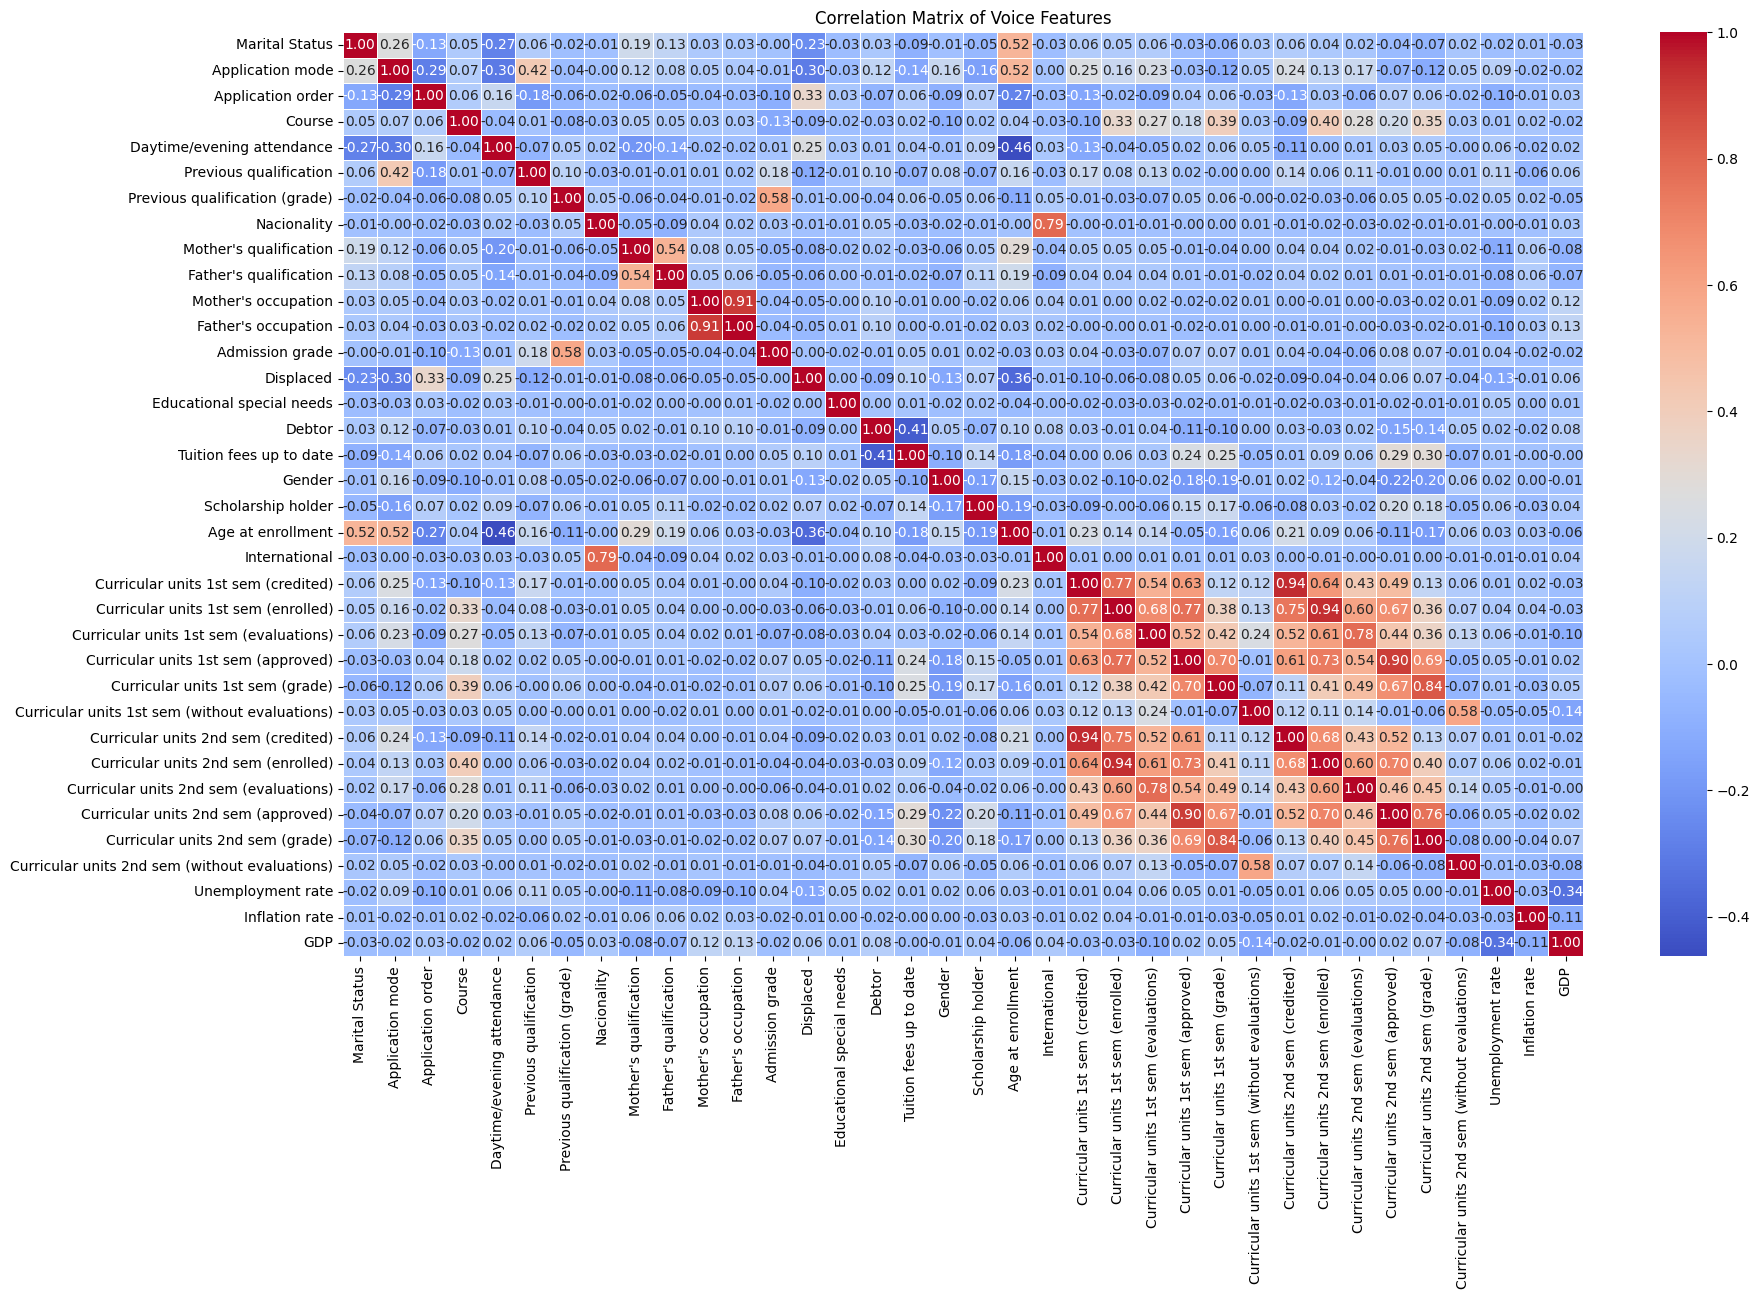

In [ ]:
#correlation matrix of the features
# Compute the correlation matrix
correlation_matrix = X.corr()

# Plot the correlation matrix using a heatmap for better visualization
plt.figure(figsize=(20, 12))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of Voice Features")
plt.show()

In [ ]:
# Visualizing the target variable with others featurs with Gender


In [ ]:
# Convert target to 1D array if needed
y = y.values.ravel()

In [ ]:
# Check for duplicate column names and rename them
duplicate_cols = X.columns[X.columns.duplicated()].unique()
if len(duplicate_cols) > 0:
    print(f"Found duplicate columns: {list(duplicate_cols)}")
    print("Renaming duplicate columns...\n")

    # Rename duplicates by adding a suffix
    cols = pd.Series(X.columns)
    for dup in cols[cols.duplicated()].unique():
        dup_indices = cols[cols == dup].index
        for i, idx in enumerate(dup_indices):
            if i > 0:  # Keep first occurrence, rename others
                cols[idx] = f"{dup}_{i}"
    X.columns = cols

# Clean column names for LightGBM (remove special characters)
X.columns = X.columns.str.replace('[^A-Za-z0-9_]+', '_', regex=True)
X.columns = X.columns.str.strip('_')  # Remove leading/trailing underscores

print(f"Dataset shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Class distribution:\n{pd.Series(y).value_counts()}\n")

In [ ]:
# Convert Categorical Variable in targe y to numeric
le = LabelEncoder()
y = le.fit_transform(y)

In [ ]:
# Splitting data into train test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling our data to have a common scale
sc = StandardScaler()
X_train_scale = sc.fit_transform(X_train)
X_test_scale = sc.transform(X_test)

#Creating dictionary to store our model
models = {
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2),
    "SVM": SVC(kernel='linear', random_state=42, decision_function_shape="ovo"),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000)
}


# Storing results in a list
result = []

print("Training and evaluating models...\n")
print("=" * 80)

#Train and Evaluate each model
for model_name, model in models.items():
    print(f"\n{model_name}")
    print("-" * 80)

    #We use scale data for models that benefit from it
    if model_name in ["Logistics Regression", "KNN", "SVM"]:
      X_train_use = X_train_scale
      X_test_use = X_test_scale
    else:
      X_train_use = X_train
      X_test_use = X_test

    # Traing the model we have
    model.fit(X_train_use, y_train)
    # Making Prediction
    y_pred = model.predict(X_test_use)

    # Evaluating our Model
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Store in results
    result.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Recall": recall,
        "Precision": precision,
        "F1 Score": f1
    })

    # Displaying Result
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1 Score: {f1:.4f}")

# Creating result dataframe
results_df = pd.DataFrame(result)

# Display summary table
print("\nModel Summary:")
display(results_df)

# Find best model for each metric
print("\n" + "=" * 80)
print("\nBEST PERFORMING MODELS")
print("=" * 80)
for metric in ["Accuracy", "Recall", "Precision", "F1 Score"]:
    best_idx = results_df[metric].idxmax()
    best_model = results_df.loc[best_idx, 'Model']
    best_score = results_df.loc[best_idx, metric]
    print(f"{metric:10s}: {best_model:20s} ({best_score:.4f})")

In [ ]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create a figure with multiple subplots
fig = plt.figure(figsize=(16, 12))


ax1 = plt.subplot(2, 2, 1)
x = np.arange(len(results_df))
width = 0.2
metrics = ['Accuracy', 'Recall', 'Precision', 'F1 Score'] # Changed 'F1-Score' to 'F1 Score'
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    offset = width * (i - 1.5)
    ax1.bar(x + offset, results_df[metric], width, label=metric, color=color, alpha=0.8)

ax1.set_xlabel('Models', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Performance Metrics Comparison Across Models', fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax1.legend(loc='lower right')
ax1.set_ylim([0.5, 1.0])
ax1.grid(axis='y', alpha=0.3)

# Feature Selection

In [ ]:
# Checking Feature Importance to Retrain model with feature importance
# Get feature importances from the best model (LightGBM)
lgbm_model = models["LightGBM"]
feature_importances = lgbm_model.feature_importances_

# Create a DataFrame for feature importances
features_df = pd.DataFrame({'Feature': X.columns, 'Importance': feature_importances})

# Sort features by importance
features_df = features_df.sort_values(by='Importance', ascending=False)

# Display top features
print("Top 10 Features by Importance:")
display(features_df.head(10))

# Select the top 10 features
top_features_names = features_df.head(10)['Feature'].tolist()
print(f"\nNumber of selected features: {len(top_features_names)}")
print("Selected Features:")
print(top_features_names)

top_features = X[top_features_names]

In [ ]:
# Add visualization of the top features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df.head(10), palette='viridis')
plt.title('Top 10 Features by Importance')
plt.xlabel('Importance')

## Resplit_and_Scale_Data_with_Selected_Features

Split the dataset into training and testing sets using only the selected features, and then scale the numerical features for models that require it.


In [ ]:
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(top_features, y, test_size=0.2, random_state=42)

# Initialize and fit StandardScaler
scaler = StandardScaler()
X_train_selected_scaled = scaler.fit_transform(X_train_selected)
X_test_selected_scaled = scaler.transform(X_test_selected)

print("Data split and scaled successfully with selected features.")
print(f"Shape of X_train_selected: {X_train_selected.shape}")
print(f"Shape of X_test_selected: {X_test_selected.shape}")
print(f"Shape of X_train_selected_scaled: {X_train_selected_scaled.shape}")
print(f"Shape of X_test_selected_scaled: {X_test_selected_scaled.shape}")

## Retrain_and_Evaluate_Models_with_Selected_Features

Re-train all the defined machine learning models using the dataset with selected features and evaluate their performance.


In [ ]:
models_selected_features = {
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2),
    "SVM": SVC(kernel='linear', random_state=42, decision_function_shape="ovo"),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000)
}

# Storing results in a list for selected features
result_selected_features = []

print("Training and evaluating models with selected features...")
print("=" * 80)

# Train and Evaluate each model with selected features
for model_name, model in models_selected_features.items():
    print(f"\n{model_name}")
    print("-" * 80)

    # Use scaled data for models that benefit from it
    if model_name in ["Logistic Regression", "KNN", "SVM"]:
        X_train_use = X_train_selected_scaled
        X_test_use = X_test_selected_scaled
    else:
        X_train_use = X_train_selected
        X_test_use = X_test_selected

    # Training the model
    model.fit(X_train_use, y_train_selected)
    # Making Prediction
    y_pred_selected = model.predict(X_test_use)

    # Evaluating our Model
    accuracy = accuracy_score(y_test_selected, y_pred_selected)
    recall = recall_score(y_test_selected, y_pred_selected, average='weighted')
    precision = precision_score(y_test_selected, y_pred_selected, average='weighted')
    f1 = f1_score(y_test_selected, y_pred_selected, average='weighted')

    # Store in results
    result_selected_features.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Recall": recall,
        "Precision": precision,
        "F1 Score": f1
    })

    # Displaying Result
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"F1 Score: {f1:.4f}")

# Creating result dataframe
results_df_selected_features = pd.DataFrame(result_selected_features)

# Display summary table
print("\nModel Summary (Selected Features):")
display(results_df_selected_features)


## Compare Model Performance

### Subtask:
Compare the performance of the machine learning models with and without feature selection.


In [ ]:
print("\nModel Performance (Full Features):")
display(results_df)

print("\nModel Performance (Selected Features):")
display(results_df_selected_features)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


metrics = ['Accuracy', 'Recall', 'Precision', 'F1 Score']

plt.figure(figsize=(18, 12))

for i, metric in enumerate(metrics):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid for subplots
    sns.barplot(data=combined_results_df, x='Model', y=metric, hue='Feature Set', palette='viridis')
    plt.title(f'Comparison of {metric} Across Models', fontsize=14)
    plt.ylabel(metric, fontsize=12)
    plt.xlabel('Model', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0.65, 0.8)
    plt.legend(title='Feature Set')

plt.tight_layout()
plt.show()

# Model Extraction